# Neural Ordinary Differential Equations

This notebook introduces **Neural Ordinary Differential Equations (Neural ODEs)** following the main ideas of **Chen, Rubanova, Bettencourt, and Duvenaud (NeurIPS 2018)**.

The key idea is simple: instead of stacking many discrete layers,

$$
\mathbf{h}_{k+1} = \mathbf{h}_k + f(\mathbf{h}_k, \theta_k),
$$

we let the hidden state evolve in continuous depth or continuous time:

$$
\frac{d\mathbf{h}(t)}{dt} = f\bigl(\mathbf{h}(t), t, \theta\bigr).
$$

That makes these models natural for **irregular observations**, **continuous-time prediction**, and **hybrid physical-learning models** where we already think in terms of differential equations.

In Earth science this is useful when:

- observations arrive at irregular times,
- a mechanistic model already provides part of the right-hand side,
- we want a learned correction or closure term,
- we care more about trajectories than about fixed-depth feedforward stacks.

While going beyond what is covered in this notebook I highly recommend you check out the following tutorial set, which will give a deeper understanding of the history, theory, and downstream implications of this topic: https://implicit-layers-tutorial.org/

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
import torch.optim as optim

rng = np.random.default_rng(7)
torch.manual_seed(7)

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

device = torch.device('cpu')
device


device(type='cpu')

## 1. From residual blocks to continuous depth

Chen et al. motivate Neural ODEs by viewing a residual network as a numerical integrator.

A residual block updates the hidden state as

$$
\mathbf{h}_{k+1} = \mathbf{h}_k + \Delta t\, f(\mathbf{h}_k, t_k, \theta),
$$

which is exactly the **forward Euler** method for the ODE

$$
\frac{d\mathbf{h}(t)}{dt} = f(\mathbf{h}(t), t, \theta).
$$

As the layer spacing gets smaller, the stack approaches a continuous transformation. The original paper highlights three important consequences:

- **Adaptive computation**: the solver decides how many function evaluations are needed.
- **Constant-memory training in principle**: via the adjoint sensitivity method.
- **Natural continuous-time modeling**: one model can be queried at any time, not only at fixed discrete steps.

We will make that first idea concrete by comparing Euler-style residual steps against a dense ODE trajectory for a simple linear spiral system.


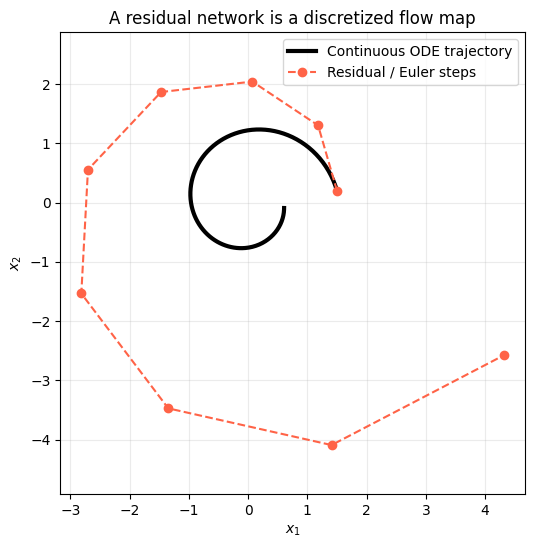

In [2]:
A_demo = np.array([[-0.15, -1.00], [1.00, -0.15]])
x0_demo = np.array([1.5, 0.2])
t_dense_demo = np.linspace(0.0, 6.0, 300)

def linear_rhs(t, x, A):
    return A @ x

sol_demo = solve_ivp(linear_rhs, (t_dense_demo[0], t_dense_demo[-1]), x0_demo, t_eval=t_dense_demo, args=(A_demo,))

dt = 0.75
steps = int((t_dense_demo[-1] - t_dense_demo[0]) / dt)
euler_path = [x0_demo.copy()]
x = x0_demo.copy()
for _ in range(steps):
    x = x + dt * (A_demo @ x)
    euler_path.append(x.copy())
euler_path = np.array(euler_path)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(sol_demo.y[0], sol_demo.y[1], lw=3, color='black', label='Continuous ODE trajectory')
ax.plot(euler_path[:, 0], euler_path[:, 1], 'o--', color='tomato', label='Residual / Euler steps')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('A residual network is a discretized flow map')
ax.axis('equal')
ax.legend();


The red points are exactly the intuition behind the paper: a residual network advances the state in finite jumps, while a Neural ODE defines a **vector field** that can be solved at whatever resolution we need.

In the original Neural ODE formulation, the solver is treated as a black box:

$$
\mathbf{h}(t_1) = \text{ODESolve}\bigl(\mathbf{h}(t_0), f, t_0, t_1, \theta\bigr).
$$

For teaching purposes we will write a small fixed-step RK4 solver ourselves so every line is visible.


## 2. A minimal differentiable ODE solver in PyTorch

The paper uses adaptive black-box solvers and trains them with the **adjoint sensitivity method**. Here we keep the implementation simple and differentiate directly through a fixed-step **Runge-Kutta 4 (RK4)** solver.

That is not the full adjoint method from Chen et al., but it preserves the central modeling idea:

- learn a vector field $f_\theta$,
- integrate it over a requested time interval,
- compare the resulting trajectory to data.


In [3]:
def rk4_step(func, z, t0, t1):
    h = t1 - t0
    k1 = func(z, t0)
    k2 = func(z + 0.5 * h * k1, t0 + 0.5 * h)
    k3 = func(z + 0.5 * h * k2, t0 + 0.5 * h)
    k4 = func(z + h * k3, t1)
    return z + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_fixed(func, z0, t_eval):
    states = [z0]
    z = z0
    for i in range(len(t_eval) - 1):
        z = rk4_step(func, z, t_eval[i], t_eval[i + 1])
        states.append(z)
    return torch.stack(states, dim=0)


## 3. Synthetic continuous-time data with irregular observations

To show why Neural ODEs are useful, we create data from a known 2D dynamical system and then observe it at **irregular times**.

This is closer to many real scientific settings than the standard fixed-step sequence assumption. Satellite passes, field campaigns, and missing observations often produce uneven temporal spacing.

Our true system is a damped rotating mode:

$$
\frac{d\mathbf{x}}{dt} = A\mathbf{x}, \quad
A = \begin{bmatrix}
-0.12 & -1.0 \\
1.0 & -0.12
\end{bmatrix}.
$$


torch.Size([14, 2])

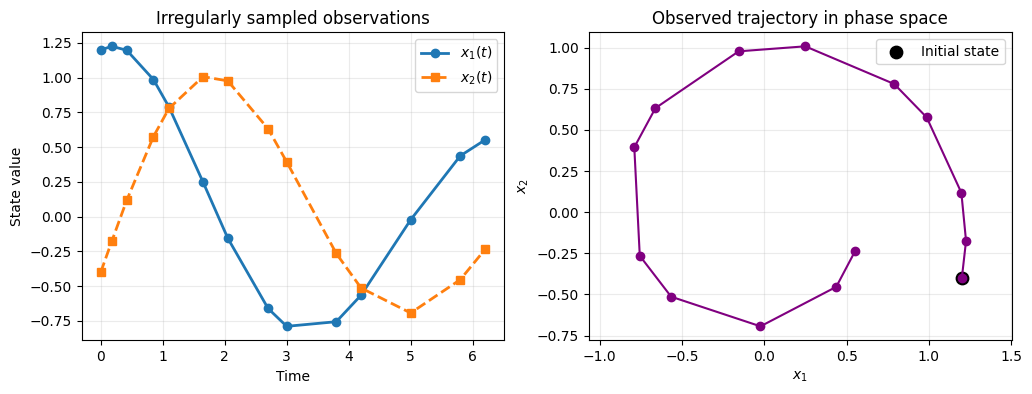

In [4]:
A_true = np.array([[-0.12, -1.00], [1.00, -0.12]])
x0_true = np.array([1.2, -0.4])

t_obs = np.array([0.0, 0.18, 0.42, 0.85, 1.10, 1.65, 2.05, 2.70, 3.00, 3.80, 4.20, 5.00, 5.80, 6.20], dtype=np.float32)
sol_true = solve_ivp(linear_rhs, (t_obs.min(), t_obs.max()), x0_true, t_eval=t_obs, args=(A_true,))
x_obs = sol_true.y.T

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_obs, x_obs[:, 0], 'o-', lw=2, label='$x_1(t)$')
axes[0].plot(t_obs, x_obs[:, 1], 's--', lw=2, label='$x_2(t)$')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('State value')
axes[0].set_title('Irregularly sampled observations')
axes[0].legend()

axes[1].plot(x_obs[:, 0], x_obs[:, 1], 'o-', color='purple')
axes[1].scatter(x_obs[0, 0], x_obs[0, 1], s=80, color='black', label='Initial state')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_title('Observed trajectory in phase space')
axes[1].axis('equal')
axes[1].legend();

t_train = torch.tensor(t_obs, dtype=torch.float32, device=device)
x_train = torch.tensor(x_obs, dtype=torch.float32, device=device)
x_train.shape


## 4. Define a Neural ODE model

We now replace the known linear operator $A$ with a neural network $f_\theta(\mathbf{x}, t)$.

The model still has the same continuous-time structure:

$$
\frac{d\mathbf{x}(t)}{dt} = f_\theta(\mathbf{x}(t), t).
$$

The only learned object is the vector field. The trajectory itself is produced by solving the ODE.

This separation is what makes Neural ODEs attractive for hybrid modeling. If physics already gives part of the dynamics, we can write

$$
\frac{d\mathbf{x}}{dt} = g_{\mathrm{phys}}(\mathbf{x}, t) + g_{\mathrm{nn}}(\mathbf{x}, t),
$$

and let the neural network learn only the missing process.


In [5]:
class ODEFunc(nn.Module):
    def __init__(self, state_dim=2, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + 1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, state_dim),
        )

    def forward(self, z, t):
        t_feature = torch.full((1,), float(t), dtype=z.dtype, device=z.device)
        return self.net(torch.cat([z, t_feature], dim=0))

class NeuralODE(nn.Module):
    def __init__(self, state_dim=2, hidden_dim=32):
        super().__init__()
        self.func = ODEFunc(state_dim=state_dim, hidden_dim=hidden_dim)

    def forward(self, z0, t_eval):
        return odeint_fixed(self.func, z0, t_eval)

model = NeuralODE(state_dim=2, hidden_dim=32).to(device)
sum(p.numel() for p in model.parameters())


1250

## 5. Train the Neural ODE on the observed trajectory

We supervise the model directly on the observed states. Starting from the first observation, the Neural ODE integrates forward to each requested time in `t_train` and we minimize mean-squared error on the whole trajectory.

This is exactly the modeling pattern emphasized in the original paper: define a vector field, call an ODE solver, and differentiate a loss through the solution.


In [6]:
model = NeuralODE(state_dim=2, hidden_dim=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-5)

epochs = 1200
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    pred = model(x_train[0], t_train)
    loss = torch.mean((pred - x_train) ** 2)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    loss_history.append(loss.item())
    if epoch % 200 == 0:
        print(f'Epoch {epoch:4d} | MSE = {loss.item():.6f}')

print(f'Final MSE = {loss_history[-1]:.6f}')


Epoch    0 | MSE = 0.560268
Epoch  200 | MSE = 0.000364
Epoch  400 | MSE = 0.000126
Epoch  600 | MSE = 0.000050
Epoch  800 | MSE = 0.000030
Epoch 1000 | MSE = 0.000022
Final MSE = 0.000029


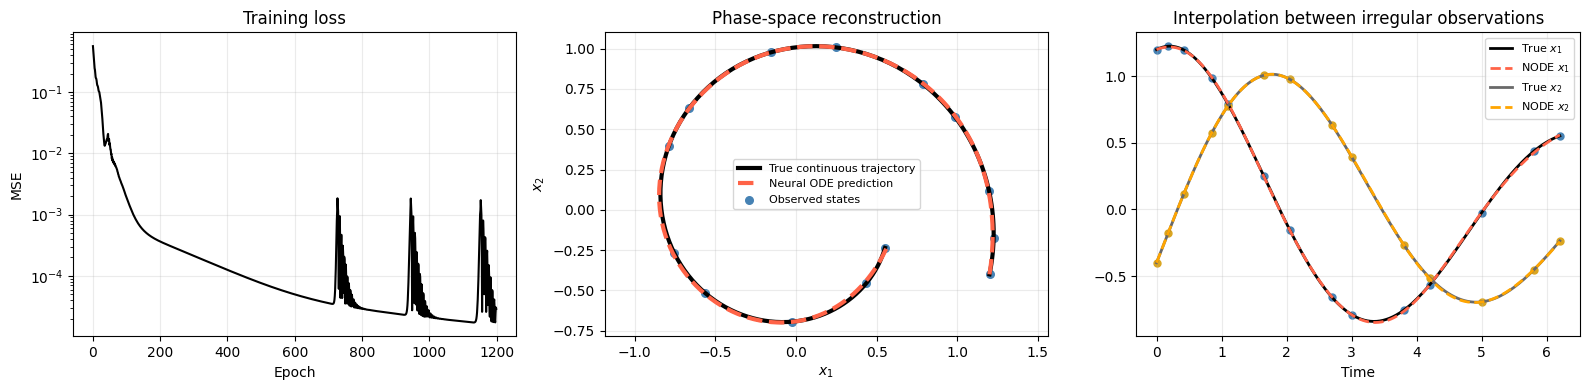

In [7]:
t_dense = np.linspace(t_obs.min(), t_obs.max(), 250, dtype=np.float32)
sol_dense_true = solve_ivp(linear_rhs, (t_dense.min(), t_dense.max()), x0_true, t_eval=t_dense, args=(A_true,))

with torch.no_grad():
    pred_train = model(x_train[0], t_train).cpu().numpy()
    pred_dense = model(x_train[0], torch.tensor(t_dense, dtype=torch.float32, device=device)).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(loss_history, color='black')
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Training loss')

axes[1].plot(sol_dense_true.y[0], sol_dense_true.y[1], lw=3, color='black', label='True continuous trajectory')
axes[1].plot(pred_dense[:, 0], pred_dense[:, 1], '--', lw=3, color='tomato', label='Neural ODE prediction')
axes[1].scatter(x_obs[:, 0], x_obs[:, 1], s=30, color='steelblue', label='Observed states')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].set_title('Phase-space reconstruction')
axes[1].axis('equal')
axes[1].legend(fontsize=8)

axes[2].plot(t_dense, sol_dense_true.y[0], color='black', lw=2, label='True $x_1$')
axes[2].plot(t_dense, pred_dense[:, 0], '--', color='tomato', lw=2, label='NODE $x_1$')
axes[2].scatter(t_obs, x_obs[:, 0], color='steelblue', s=25)
axes[2].plot(t_dense, sol_dense_true.y[1], color='dimgray', lw=2, label='True $x_2$')
axes[2].plot(t_dense, pred_dense[:, 1], '--', color='orange', lw=2, label='NODE $x_2$')
axes[2].scatter(t_obs, x_obs[:, 1], color='goldenrod', s=25)
axes[2].set_xlabel('Time')
axes[2].set_title('Interpolation between irregular observations')
axes[2].legend(fontsize=8)

plt.tight_layout()


A useful diagnostic is the learned **vector field** itself. If the model has captured the underlying dynamics, the arrows of the learned field should resemble the true damped rotation.


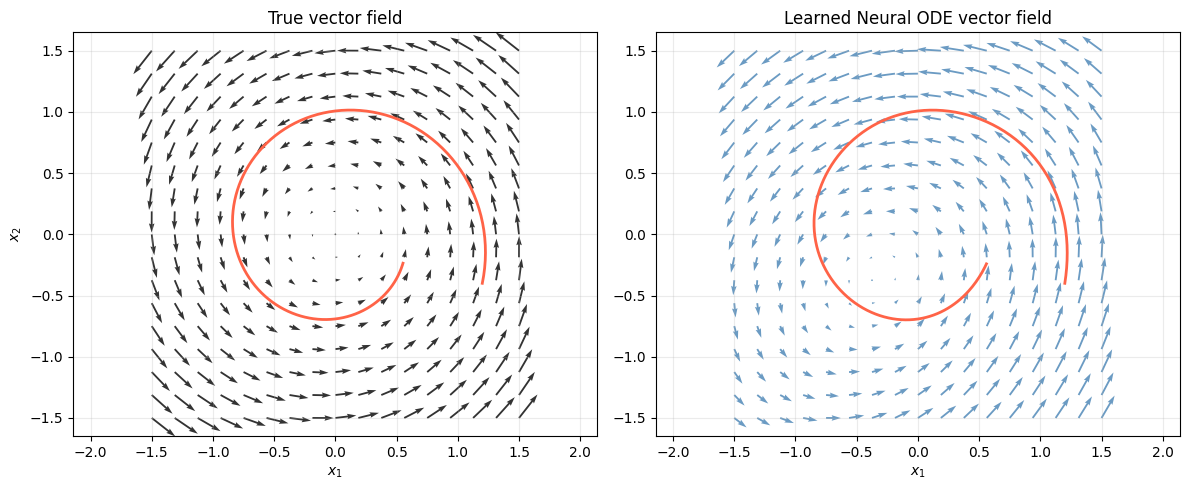

In [8]:
grid = np.linspace(-1.5, 1.5, 17)
X1, X2 = np.meshgrid(grid, grid)
U_true = np.zeros_like(X1)
V_true = np.zeros_like(X2)
U_learned = np.zeros_like(X1)
V_learned = np.zeros_like(X2)

with torch.no_grad():
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            state = np.array([X1[i, j], X2[i, j]])
            dtrue = A_true @ state
            U_true[i, j], V_true[i, j] = dtrue

            z = torch.tensor(state, dtype=torch.float32, device=device)
            dlearn = model.func(z, torch.tensor(0.0, dtype=torch.float32, device=device)).cpu().numpy()
            U_learned[i, j], V_learned[i, j] = dlearn

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].quiver(X1, X2, U_true, V_true, color='black', alpha=0.8)
axes[0].plot(sol_dense_true.y[0], sol_dense_true.y[1], color='tomato', lw=2)
axes[0].set_title('True vector field')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].axis('equal')

axes[1].quiver(X1, X2, U_learned, V_learned, color='steelblue', alpha=0.8)
axes[1].plot(pred_dense[:, 0], pred_dense[:, 1], color='tomato', lw=2)
axes[1].set_title('Learned Neural ODE vector field')
axes[1].set_xlabel('$x_1$')
axes[1].axis('equal')

plt.tight_layout()


## 6. What this notebook simplifies relative to Chen et al. (2018)

The original paper contains several ideas beyond what we implemented here.

| Paper idea | Role in the original work | What we did here |
|---|---|---|
| **Black-box ODE solver** | Integrate the hidden state with adaptive stepping | Used a transparent fixed-step RK4 solver |
| **Adjoint sensitivity method** | Backpropagate through the ODE with low memory cost | Differentiated directly through RK4 for clarity |
| **Continuous-depth ResNets** | Replace discrete residual blocks in supervised learning | Focused on a low-dimensional dynamical system |
| **Continuous normalizing flows** | Make density evolution cheaper via a trace term | Omitted |
| **Irregular time-series / latent ODEs** | Handle observations at arbitrary times | Captured the irregular-time motivation in a simple supervised example |

So this notebook preserves the **modeling viewpoint** of the paper without reproducing every algorithmic detail.


## 7. Continuous normalizing flows: the generative-model bridge

One of the most important extensions in Chen et al. is the move from ODEs for hidden states to ODEs for **probability densities**.

In an ordinary normalizing flow, we transform a random variable through a sequence of invertible maps and track how the density changes using the Jacobian determinant. In the continuous-time limit, this becomes a **continuous normalizing flow (CNF)**:

$$
\frac{d\mathbf{z}(t)}{dt} = f\bigl(\mathbf{z}(t), t, \theta\bigr).
$$

The key result from the paper is that the log-density evolves according to

$$
\frac{\partial \log p(\mathbf{z}(t))}{\partial t} = -\operatorname{tr}\!\left(\frac{\partial f}{\partial \mathbf{z}(t)}\right).
$$

This is important because a **trace** is much cheaper to work with than a full **log-determinant**. That makes continuous-time generative modeling substantially more scalable than many discrete flow constructions.

Conceptually, this is the bridge to later generative models:

- **Neural ODE**: evolve a hidden state through a learned vector field.
- **Continuous normalizing flow**: evolve both the sample and its probability density through that vector field.
- **Diffusion / score-based models**: also define continuous-time transformations of distributions, but typically through stochastic differential equations or probability-flow ODEs.

So when students later see diffusion models, the unfamiliar part is not the continuous-time viewpoint. The new ingredient is that the dynamics are designed to transport an easy distribution into a complex data distribution while keeping track of probability or score information.

A useful mental model is:

- **Neural ODEs** learn trajectories of states.
- **CNFs** learn trajectories of states plus densities.
- **Diffusion models** learn trajectories of distributions under noise and denoising dynamics.

That is why CNFs are an important future bridge topic: they connect dynamical systems language directly to modern generative modeling.


## 8. Why Neural ODEs matter for hybrid modeling in Earth science

Neural ODEs become especially interesting when combined with known process equations.

A common hybrid pattern is

$$
\frac{d\mathbf{x}}{dt} = g_{\mathrm{phys}}(\mathbf{x}, t, \phi) + g_{\mathrm{nn}}(\mathbf{x}, t, \theta),
$$

where:

- $g_{\mathrm{phys}}$ is a trusted mechanistic core,
- $g_{\mathrm{nn}}$ is a learned closure, bias correction, or unresolved subgrid process.

Examples:

- learning missing source or sink terms in a carbon-box model,
- correcting structural bias in a runoff reservoir model,
- learning unresolved chemistry or mixing tendencies,
- assimilating irregular observations without forcing everything onto one discrete grid.

The strength of the Neural ODE formulation is that the learning problem stays aligned with the language of dynamical systems.


## 9. Summary

| Concept | Key point |
|---|---|
| **Residual block** | A discrete Euler-like step in hidden space |
| **Neural ODE** | Learns the derivative $d\mathbf{h}/dt = f_\theta(\mathbf{h}, t)$ |
| **Solver** | Produces the model output by integrating the vector field |
| **Continuous normalizing flow** | Tracks how both samples and densities evolve through continuous dynamics |
| **Why continuous time helps** | Handles irregular sampling and supports interpolation/extrapolation in time |
| **Why it matters for hybrid models** | Physics and neural corrections can be added in the same differential equation |
| **Original Chen et al. contribution** | Continuous-depth networks, adjoint backpropagation, and adaptive solver-based learning |

Reference:

Ricky T. Q. Chen, Yulia Rubanova, Jesse Bettencourt, and David Duvenaud, **Neural Ordinary Differential Equations**, NeurIPS 2018.
